In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pydicom

In [2]:
DATA_DIR = Path("../data/raw/test_studies")

dicom_files = list(DATA_DIR.iterdir())

print(f"Archivos encontrados: {len(dicom_files)}")

Archivos encontrados: 90


In [9]:
datasets = [
    pydicom.dcmread(path) 
    for path in dicom_files
]

In [19]:
for name in [
    "StudyInstanceUID",
    "SeriesInstanceUID",
    "Modality"
]: 
    values = {
        ds.get(name)
        for ds in datasets
    }
    
    print(f"{name}:")
    print(values)
    print()

StudyInstanceUID:
{'1.3.6.1.4.1.14519.5.2.1.11784217633835209751588758740160819597'}

SeriesInstanceUID:
{'1.3.6.1.4.1.14519.5.2.1.311251873679098488391157318475172879927'}

Modality:
{'MR'}



In [17]:
spatial_tags = [
    "ImagePositionPatient",
    "ImageOrientationPatient",
    "PixelData",
    "PixelSpacing",
    "SliceThickness",
    "SpacingBetweenSlices",
    "Rows",
    "Columns",
]

for tag in spatial_tags:
    values = {
        str(ds.get(tag))
        for ds in datasets
    }

    print(f"{tag}:")
    print(values)
    print()

ImagePositionPatient:
{'[-111.732, -125.791, 60.8998]', '[-111.732, -125.791, -37.1002]', '[-111.732, -125.791, -23.1002]', '[-111.732, -125.791, -33.1002]', '[-111.732, -125.791, 84.8998]', '[-111.732, -125.791, 0.899845]', '[-111.732, -125.791, 126.9]', '[-111.732, -125.791, 72.8998]', '[-111.732, -125.791, 20.8998]', '[-111.732, -125.791, 104.9]', '[-111.732, -125.791, 8.89985]', '[-111.732, -125.791, 54.8998]', '[-111.732, -125.791, 10.8998]', '[-111.732, -125.791, 28.8998]', '[-111.732, -125.791, -13.1002]', '[-111.732, -125.791, -25.1002]', '[-111.732, -125.791, 66.8998]', '[-111.732, -125.791, 6.89985]', '[-111.732, -125.791, 62.8998]', '[-111.732, -125.791, 92.8998]', '[-111.732, -125.791, -7.10015]', '[-111.732, -125.791, -3.10015]', '[-111.732, -125.791, -29.1002]', '[-111.732, -125.791, -41.1002]', '[-111.732, -125.791, 86.8998]', '[-111.732, -125.791, 36.8998]', '[-111.732, -125.791, 112.9]', '[-111.732, -125.791, -43.1002]', '[-111.732, -125.791, -15.1002]', '[-111.732, -1

In [10]:
for i, ds in enumerate(datasets[:5]):
    print(
        f"Slice {i}: "
        f"{ds.get('ImagePositionPatient')}"
    )

Slice 0: [-111.732, -125.791, -13.1002]
Slice 1: [-111.732, -125.791, 84.8998]
Slice 2: [-111.732, -125.791, 50.8998]
Slice 3: [-111.732, -125.791, -9.10015]
Slice 4: [-111.732, -125.791, -3.10015]


In [11]:
orientation = datasets[0].get("ImageOrientationPatient")

print(orientation)

[1, 0, -1.90638e-11, 0, 1, 0]


In [13]:
orientation = np.array(
    datasets[0].ImageOrientationPatient,
    dtype=float
)

row_direction = orientation[:3]
column_direction = orientation[3:]

slice_direction = np.cross(
    row_direction,
    column_direction
)

print("Row:", row_direction)
print("Column:", column_direction)
print("Slice:", slice_direction)

Row: [ 1.00000e+00  0.00000e+00 -1.90638e-11]
Column: [0. 1. 0.]
Slice: [ 1.90638e-11 -0.00000e+00  1.00000e+00]


In [14]:
def slice_position(ds, direction):
    position = np.array(
        ds.ImagePositionPatient,
        dtype=float
    )

    return np.dot(position, direction)

ordered_datasets = sorted(
    datasets,
    key=lambda ds: slice_position(ds, slice_direction)
)

In [15]:
positions = [
    slice_position(ds, slice_direction)
    for ds in ordered_datasets
]

for i, position in enumerate(positions[:10]):
    print(f"Slice {i}: {position}")

Slice 0: -51.10020000213004
Slice 1: -49.10020000213004
Slice 2: -47.10020000213004
Slice 3: -45.10020000213004
Slice 4: -43.10020000213004
Slice 5: -41.10020000213004
Slice 6: -39.10020000213004
Slice 7: -37.10020000213004
Slice 8: -35.10020000213004
Slice 9: -33.10020000213004


In [16]:
differences = np.diff(positions)

print("Espaciados:")
print(differences)

print(
    "Espaciado medio:",
    np.mean(np.abs(differences))
)

Espaciados:
[2.       2.       2.       2.       2.       2.       2.       2.
 2.       2.       2.       2.       2.       2.       2.       2.
 2.       2.       2.       2.       2.00005  2.       2.       2.
 2.       1.999995 2.000005 2.       2.       2.       1.99995  2.
 2.       2.       2.       2.       2.       2.       2.       2.
 2.       2.       2.       2.       2.       2.       2.       2.
 2.       2.       2.       2.       2.       2.       2.       2.
 2.       2.       2.       2.       2.       2.       2.       2.
 2.       2.       2.       2.       2.       2.       2.       2.
 2.       2.       2.       2.0002   2.       2.       2.       2.
 2.       2.       2.       2.       2.       2.       2.       2.
 2.      ]
Espaciado medio: 2.0000022471910115


In [11]:
ds = datasets[0]

print("PixelData:", "PixelData" in ds)
print("Shape:", ds.pixel_array.shape)
print("Dtype:", ds.pixel_array.dtype)

PixelData: True
Shape: (256, 256)
Dtype: uint16


In [17]:
volume = np.stack([
    ds.pixel_array
    for ds in ordered_datasets
])

print(volume.shape)
print(volume.dtype)

(90, 256, 256)
uint16


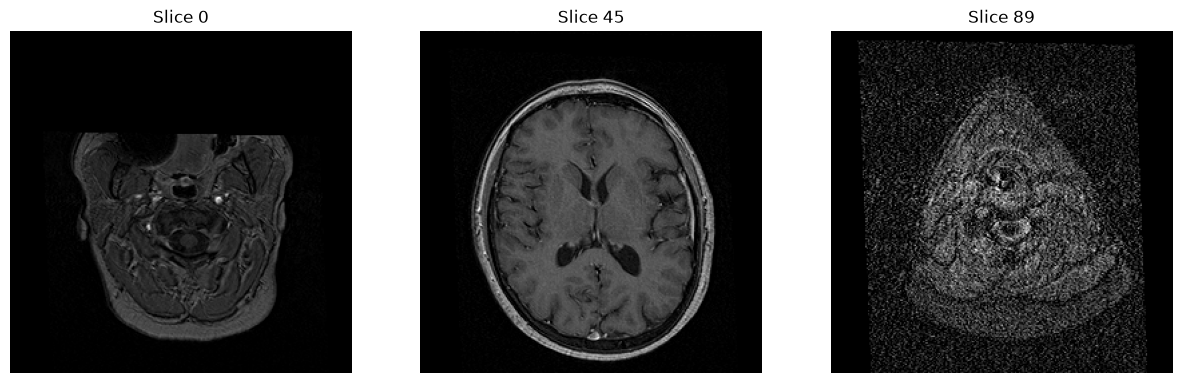

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

indices = [
    0,
    len(volume) // 2,
    len(volume) - 1
]

for ax, index in zip(axes, indices):
    ax.imshow(volume[index], cmap="gray")
    ax.set_title(f"Slice {index}")
    ax.axis("off")

plt.show()

In [3]:
from pathlib import Path

from mri_dataset_tool.infrastructure.dicom.reader import DICOMReader

reader = DICOMReader()

study = reader.load_study(
    DATA_DIR
)

In [4]:
print(study.study_uid)
print(len(study.series))

1.3.6.1.4.1.14519.5.2.1.11784217633835209751588758740160819597
1


In [5]:
series = study.series[0]

print("Series UID:", series.series_uid)
print("Modality:", series.modality)
print("Files:", len(series.files))

Series UID: 1.3.6.1.4.1.14519.5.2.1.311251873679098488391157318475172879927
Modality: MR
Files: 90


In [6]:
print(series.get("rows"))
print(series.get("columns"))
print(series.get("pixel_spacing"))
print(series.get("slice_thickness"))
print(series.get("image_orientation"))

256
256
[0.898438, 0.898438]
2
[1, 0, -1.90638e-11, 0, 1, 0]
